In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import xarray as xr
from klepto.archives import file_archive
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import numpy.ma as ma

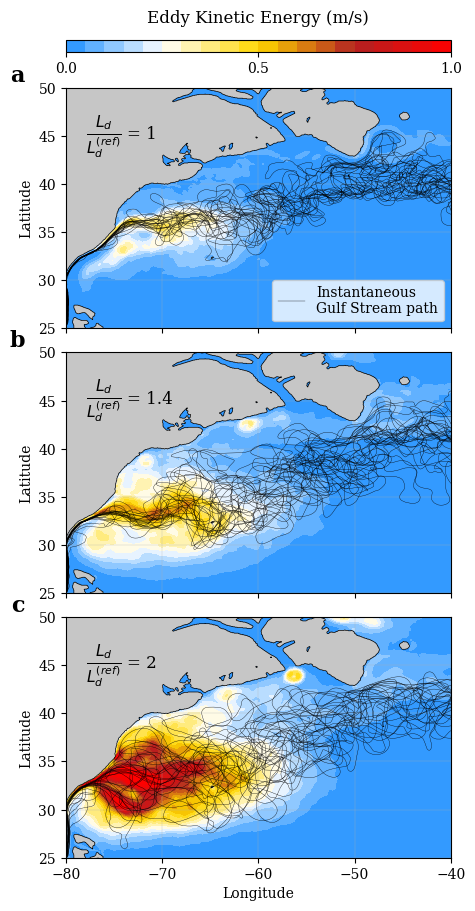

In [3]:
savepath = "data/"

lat_min = 25
lat_max = 50
lon_min = -80
lon_max = -40

drho_facs = [1, 2, 4]

plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(5, 10))
grid = plt.GridSpec(3, 1, hspace=0.1, wspace=0)

cs = ["dodgerblue", "white", "gold", "firebrick", "red"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("cmap_name", cs)

Rd_labels = ["1", "1.4", "2"]
labels = ["a", "b", "c"]
R0 = 39066.430787677964

for i, drho_fac in enumerate(drho_facs):
        
    drho = np.array([ 2.13, 1.72, 1.41, 1.01, 0. ])[::-1]*drho_fac
    
    # open datasets
    
    # topo mask 
    ds_topo = xr.open_dataset(savepath + "topo.nc")
    topo = ds_topo["zb"][0,0,:,:]
    mask = topo < 0
    mx = ma.masked_array(np.zeros(np.shape(topo)), mask=mask)
    zeros = topo*0
          
    # eke
    ds_std = xr.open_dataset(savepath + "U_std_2048_" + str(drho_fac) + "drho.nc", decode_times=False)
    eke = ds_std["__xarray_dataarray_variable__"][-1,:,:]**2
    lat_mod = eke.y
    lon_mod = eke.x
    
    axes = fig.add_subplot(grid[i])

    #  kinetic energy

    v = 1
    levels = np.linspace(0, v, 21)
    
    axes.pcolormesh(lon_mod, lat_mod, eke, vmin = 0, vmax = v, cmap = cmap)
    cplot = axes.contourf(lon_mod, lat_mod, eke, vmin = 0, vmax = v, levels = levels, cmap = cmap)

    # coastlines
    axes.pcolormesh(lon_mod, lat_mod, mx, cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
    axes.contour(lon_mod, lat_mod, topo, levels = [0], colors = "k", linewidths = 0.5)

    if i == 2:
        axes.set_xlabel("Longitude")
    else:
        axes.set_xticklabels([])
    axes.set_ylabel("Latitude")

    axes.text(-0.125, 1.05, labels[i], weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
    
    axes.set_xticks(np.linspace(-80, -40, 5))
    
    if i == 0:
            
        divider = make_axes_locatable(axes)
        cax = axes.inset_axes((0, 1.15,1, 0.05))
        
        cbar = plt.colorbar(cplot, cax=cax, orientation='horizontal', ticks=[0,0.5, 1])
        cax.set_xlabel("Eddy Kinetic Energy (m/s)", size = 12, rotation = 0)
        cax.xaxis.set_label_coords(0.5,3.5)
        
    # add grid
    axes.grid(zorder = 1, linewidth = 0.2)
    
    # set lateral and longitudinal extend
    axes.set_xlim([lon_min, lon_max])
    axes.set_ylim([lat_min, lat_max])
    axes.set_aspect(1)

    # add text for deformation radius
    axes.text(0.1, 0.8, r'$\frac{L_d}{L_d^{(ref)}}$', horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
    axes.text(0.16, 0.8075, '= ' + Rd_labels[i], verticalalignment='center', transform=axes.transAxes, size = 12)

    # add spaghettis
    conts_load = np.load(savepath + "conts_" + str(drho_fac) + "drho.npz", allow_pickle=False)
    N_cont = len(conts_load) - 1
    for j in range(0, 200, 10):
        if i == 0 and j == 0:
            cont = conts_load[str(j)]
            plt.plot(cont[0,:], cont[1,:], linewidth = 0.25, alpha = 1, color = "k", label = "Instantaneous\nGulf Stream path")
            plt.legend(loc = "lower right")
        else:
            cont = conts_load[str(j)]
            plt.plot(cont[0,:], cont[1,:], linewidth = 0.25, alpha = 1, color = "k")
    
    # # mean spaghetti
    # ds_topo = xr.open_dataset(savepath + "gulf_" + str(drho_fac) + "drho_isopycs_mean.nc")
    # ssh_mean = ds_topo["h"][-1,:,:]
    # cont = calc_cont(ssh_mean)
    # if i == 0:
    #     #plt.plot(cont[0,:], cont[1,:], linewidth = 2, alpha = 1, color = "k", label = "Time-average\nGulf Stream path")
    #     plt.legend(loc = "lower right")
    # else:
    #     x = 1#plt.plot(cont[0,:], cont[1,:], linewidth = 2, alpha = 1, color = "k",)
        
plt.savefig('gulf_stream_spaghetti_EKE_no_AMOC.png', dpi = 200, bbox_inches='tight', format = 'png')